In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# paths
current_dir = os.getcwd()
project_dir = os.path.dirname(current_dir)

processed_dir = os.path.join(project_dir, "data", "processed")
output_dir = os.path.join(current_dir, "outputs")
figures_dir = os.path.join(output_dir, "figures")
tables_dir = os.path.join(output_dir, "tables")

os.makedirs(figures_dir, exist_ok=True)
os.makedirs(tables_dir, exist_ok=True)

merged_file = os.path.join(processed_dir, "merged_bay_sensor_data.csv")
demand_file = os.path.join(processed_dir, "cleaned_demand_data.csv")

print("Processed folder:", processed_dir)

Processed folder: c:\Users\SHARP\MOP-Code\Playground\project-27-smart-parking-demand-prediction\data\processed


In [3]:
# load cleaned data
merged_df = pd.read_csv(merged_file)
demand_df = pd.read_csv(demand_file)

print("Files loaded")
print("merged_df shape:", merged_df.shape)
print("demand_df shape:", demand_df.shape)

Files loaded
merged_df shape: (8031, 13)
demand_df shape: (1575, 5)


In [4]:
merged_df.head()

,lastupdated,status_timestamp,zone_number,status_description,kerbsideid,location,status_hour,status_day,occupied,restriction_days,time_restrictions_start,time_restrictions_finish,restriction_display
0,2025-03-25T11:44:37+11:00,2025-03-25 00:09:20+00:00,7303.0,Unoccupied,51614,"-37.81620493158199, 144.96978894261684",0,Tuesday,0,NaN,NaN,NaN,NaN
1,2025-03-25T11:44:37+11:00,2025-03-24 23:56:53+00:00,7265.0,Present,17954,"-37.81019990197624, 144.97294577505386",23,Monday,1,Mon-Fri,07:30:00,18:30:00,2P
2,2025-03-25T11:44:37+11:00,2025-03-24 23:56:53+00:00,7265.0,Present,17954,"-37.81019990197624, 144.97294577505386",23,Monday,1,Sat,07:30:00,12:30:00,2P
3,2025-03-25T11:44:37+11:00,2025-03-25 00:06:47+00:00,7529.0,Unoccupied,62710,"-37.813134438674666, 144.97067212855254",0,Tuesday,0,Mon-Fri,19:00:00,22:00:00,MP2P
4,2025-03-25T11:44:37+11:00,2025-03-25 00:06:47+00:00,7529.0,Unoccupied,62710,"-37.813134438674666, 144.97067212855254",0,Tuesday,0,Mon-Fri,16:00:00,19:00:00,MP2P


In [5]:
demand_df.head()

,zone_number,status_day,status_hour,average_occupancy,demand_level
0,7010.0,Friday,1,0.0,Low
1,7010.0,Thursday,21,1.0,High
2,7010.0,Thursday,22,1.0,High
3,7010.0,Thursday,23,1.0,High
4,7010.0,Wednesday,9,0.0,Low


In [6]:
# missing values
print(merged_df.isnull().sum())
print(demand_df.isnull().sum())

lastupdated                   0
status_timestamp              0
zone_number                 218
status_description            0
kerbsideid                    0
location                      0
status_hour                   0
status_day                    0
occupied                      0
restriction_days            248
time_restrictions_start     248
time_restrictions_finish    248
restriction_display         248
dtype: int64
zone_number          0
status_day           0
status_hour          0
average_occupancy    0
demand_level         0
dtype: int64


In [7]:
# hourly demand
hourly_demand = demand_df.groupby("status_hour", as_index=False)["average_occupancy"].mean()
hourly_demand

,status_hour,average_occupancy
0,0,0.655153
1,1,0.583063
2,2,0.422209
3,3,0.434470
4,4,0.430320
5,5,0.479306
6,6,0.536092
7,7,0.474178
8,8,0.477305
9,9,0.528624


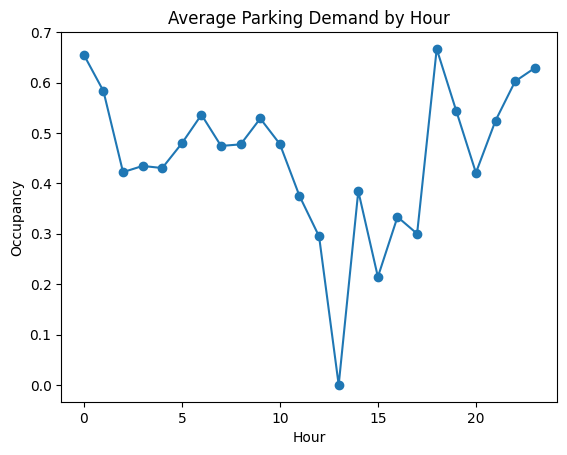

In [8]:
plt.figure()
plt.plot(hourly_demand["status_hour"], hourly_demand["average_occupancy"], marker="o")
plt.title("Average Parking Demand by Hour")
plt.xlabel("Hour")
plt.ylabel("Occupancy")
plt.show()

In [9]:
# daily demand
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
daily_demand = demand_df.groupby("status_day", as_index=False)["average_occupancy"].mean()
daily_demand["status_day"] = pd.Categorical(daily_demand["status_day"], categories=day_order, ordered=True)
daily_demand = daily_demand.sort_values("status_day")
daily_demand

,status_day,average_occupancy
1,Monday,0.541751
5,Tuesday,0.446481
6,Wednesday,0.530512
4,Thursday,0.401607
0,Friday,0.517598
2,Saturday,0.373188
3,Sunday,0.424150


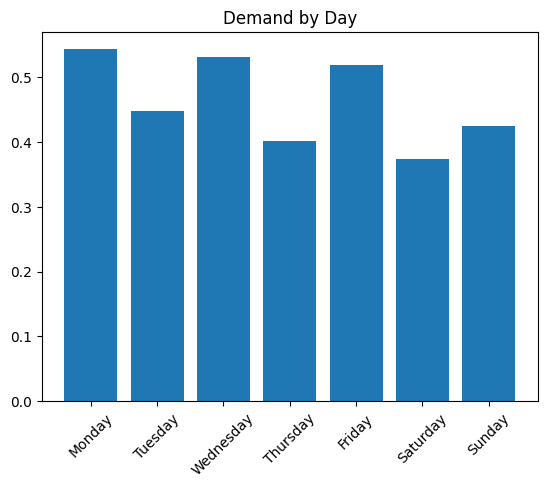

In [10]:
plt.figure()
plt.bar(daily_demand["status_day"], daily_demand["average_occupancy"])
plt.title("Demand by Day")
plt.xticks(rotation=45)
plt.show()

In [11]:
# demand distribution
demand_counts = demand_df["demand_level"].value_counts()
demand_counts

demand_level
Low       739
High      648
Medium    188
Name: count, dtype: int64

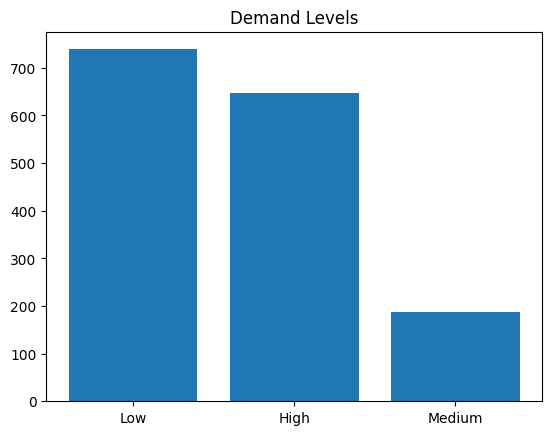

In [12]:
plt.figure()
plt.bar(demand_counts.index, demand_counts.values)
plt.title("Demand Levels")
plt.show()

In [13]:
# zone summary
zone_summary = merged_df.groupby("zone_number").agg(
    average_occupancy=("occupied","mean"),
    observation_count=("occupied","count")
).reset_index().sort_values("average_occupancy", ascending=False)

zone_summary.head()

,zone_number,average_occupancy,observation_count
30,7189.0,1.0,9
300,7762.0,1.0,9
2,7014.0,1.0,8
40,7205.0,1.0,1
51,7223.0,1.0,8


In [14]:
# correlation
numeric_cols = [col for col in ["zone_number","status_hour","is_weekend","average_occupancy"] if col in demand_df.columns]
demand_df[numeric_cols].corr(numeric_only=True)

,zone_number,status_hour,average_occupancy
zone_number,1.000000,-0.019162,-0.050079
status_hour,-0.019162,1.000000,-0.008680
average_occupancy,-0.050079,-0.008680,1.000000


In [15]:
# save outputs
hourly_demand.to_csv(os.path.join(tables_dir, "hourly_demand.csv"), index=False)
daily_demand.to_csv(os.path.join(tables_dir, "daily_demand.csv"), index=False)
zone_summary.to_csv(os.path.join(tables_dir, "zone_summary.csv"), index=False)

print("Saved tables")

Saved tables
